# Round 4 Manual: "Vanilla Just Isn't Exotic Enough"

Underlying `AETHER_CRYSTAL` is GBM with zero drift, sigma=251%, 4 steps/day, 252 days/year.
We buy/sell once at t=0 and hold to expiry. PnL is averaged across 100 sims.

**Plan**
1. Set up BS + MC pricers.
2. Verify each listed option's fair value.
3. Price the three exotics (chooser, binary put, KO put).
4. Identify edges and the natural hedges from the hint.
5. Pick a portfolio that maximizes expected PnL with bounded variance.

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Market params
S0 = 50.0
SIGMA = 2.51              # 251 %
TRADING_DAYS_PER_YEAR = 252
STEPS_PER_DAY = 4
STEPS_PER_YEAR = TRADING_DAYS_PER_YEAR * STEPS_PER_DAY

def weeks_to_years(w):
    return (w * 5) / TRADING_DAYS_PER_YEAR

def steps_for_weeks(w):
    return int(round(w * 5 * STEPS_PER_DAY))

T_2W = weeks_to_years(2)
T_3W = weeks_to_years(3)
N_2W = steps_for_weeks(2)
N_3W = steps_for_weeks(3)
print(f"T_2W = {T_2W:.5f} yr ({N_2W} steps), T_3W = {T_3W:.5f} yr ({N_3W} steps)")
print(f"sigma*sqrt(T_2W) = {SIGMA*np.sqrt(T_2W):.4f}")
print(f"sigma*sqrt(T_3W) = {SIGMA*np.sqrt(T_3W):.4f}")

T_2W = 0.03968 yr (40 steps), T_3W = 0.05952 yr (60 steps)
sigma*sqrt(T_2W) = 0.5000
sigma*sqrt(T_3W) = 0.6124


In [2]:
# Black-Scholes (r=0)
def bs_call(S, K, T, sigma=SIGMA):
    if T <= 0:
        return max(S - K, 0.0)
    sT = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + 0.5 * sT * sT) / sT
    d2 = d1 - sT
    return S * norm.cdf(d1) - K * norm.cdf(d2)

def bs_put(S, K, T, sigma=SIGMA):
    if T <= 0:
        return max(K - S, 0.0)
    sT = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + 0.5 * sT * sT) / sT
    d2 = d1 - sT
    return K * norm.cdf(-d2) - S * norm.cdf(-d1)

# Monte Carlo path simulator (matches problem's discrete grid)
def simulate_paths(n_paths, n_steps, S0=S0, sigma=SIGMA, seed=None):
    g = np.random.default_rng(seed) if seed is not None else rng
    dt = 1.0 / STEPS_PER_YEAR
    drift = -0.5 * sigma * sigma * dt
    diff = sigma * np.sqrt(dt)
    Z = g.standard_normal((n_paths, n_steps))
    log_increments = drift + diff * Z
    log_paths = np.concatenate([np.zeros((n_paths, 1)),
                                np.cumsum(log_increments, axis=1)], axis=1)
    return S0 * np.exp(log_paths)

PATHS_BIG = simulate_paths(200_000, N_3W, seed=1)
ST_3w = PATHS_BIG[:, -1]
ST_2w = PATHS_BIG[:, N_2W]
print("Vanilla check (analytic vs MC, 200k paths):")
for K in [35, 40, 45, 50]:
    bs = bs_put(S0, K, T_3W)
    mc = np.maximum(K - ST_3w, 0).mean()
    print(f"  Put K={K} 3w:  BS={bs:.4f}  MC={mc:.4f}")
for K in [50, 60]:
    bs = bs_call(S0, K, T_3W)
    mc = np.maximum(ST_3w - K, 0).mean()
    print(f"  Call K={K} 3w: BS={bs:.4f}  MC={mc:.4f}")
for K in [50]:
    bs_c = bs_call(S0, K, T_2W); mc_c = np.maximum(ST_2w - K, 0).mean()
    bs_p = bs_put(S0, K, T_2W);  mc_p = np.maximum(K - ST_2w, 0).mean()
    print(f"  Call K={K} 2w: BS={bs_c:.4f}  MC={mc_c:.4f}")
    print(f"  Put  K={K} 2w: BS={bs_p:.4f}  MC={mc_p:.4f}")

Vanilla check (analytic vs MC, 200k paths):
  Put K=35 3w:  BS=4.3361  MC=4.3048
  Put K=40 3w:  BS=6.5095  MC=6.4678
  Put K=45 3w:  BS=9.0889  MC=9.0365
  Put K=50 3w:  BS=12.0269  MC=11.9642
  Call K=50 3w: BS=12.0269  MC=12.0680
  Call K=60 3w: BS=8.7918  MC=8.8104
  Call K=50 2w: BS=9.8707  MC=9.8633
  Put  K=50 2w: BS=9.8707  MC=9.8155


## Step 1 - Compare listed mids to fair value

We list every product, its mid, BS fair, and per-unit edge for buying-at-ask vs selling-at-bid.
Edges are unscaled (per option); multiply by limit and 3000 (contract size) for XIRECS.

In [3]:
quotes = {
    'AC':         (49.975, 50.025),
    'AC_50_P':    (12.00,  12.05),
    'AC_50_C':    (12.00,  12.05),
    'AC_35_P':    ( 4.33,   4.35),
    'AC_40_P':    ( 6.50,   6.55),
    'AC_45_P':    ( 9.05,   9.10),
    'AC_60_C':    ( 8.80,   8.85),
    'AC_50_P_2':  ( 9.70,   9.75),
    'AC_50_C_2':  ( 9.70,   9.75),
    'AC_50_CO':   (22.20,  22.30),
    'AC_40_BP':   ( 5.00,   5.10),
    'AC_45_KO':   ( 0.150,  0.175),
}
limits = {
    'AC': 200, 'AC_50_P':50, 'AC_50_C':50, 'AC_35_P':50, 'AC_40_P':50, 'AC_45_P':50,
    'AC_60_C':50, 'AC_50_P_2':50, 'AC_50_C_2':50, 'AC_50_CO':50, 'AC_40_BP':50, 'AC_45_KO':500
}

vanilla_fair = {
    'AC':         50.0,
    'AC_50_P':    bs_put (S0, 50, T_3W),
    'AC_50_C':    bs_call(S0, 50, T_3W),
    'AC_35_P':    bs_put (S0, 35, T_3W),
    'AC_40_P':    bs_put (S0, 40, T_3W),
    'AC_45_P':    bs_put (S0, 45, T_3W),
    'AC_60_C':    bs_call(S0, 60, T_3W),
    'AC_50_P_2':  bs_put (S0, 50, T_2W),
    'AC_50_C_2':  bs_call(S0, 50, T_2W),
}

print(f"{'Product':<11}{'Bid':>8}{'Ask':>8}{'Mid':>8}{'Fair':>10}{'BuyEdge':>10}{'SellEdge':>10}")
for k, fair in vanilla_fair.items():
    b, a = quotes[k]; mid = (b + a) / 2
    print(f"{k:<11}{b:>8.3f}{a:>8.3f}{mid:>8.3f}{fair:>10.4f}{fair-a:>10.4f}{b-fair:>10.4f}")

Product         Bid     Ask     Mid      Fair   BuyEdge  SellEdge
AC           49.975  50.025  50.000   50.0000   -0.0250   -0.0250
AC_50_P      12.000  12.050  12.025   12.0269   -0.0231   -0.0269
AC_50_C      12.000  12.050  12.025   12.0269   -0.0231   -0.0269
AC_35_P       4.330   4.350   4.340    4.3361   -0.0139   -0.0061
AC_40_P       6.500   6.550   6.525    6.5095   -0.0405   -0.0095
AC_45_P       9.050   9.100   9.075    9.0889   -0.0111   -0.0389
AC_60_C       8.800   8.850   8.825    8.7918   -0.0582    0.0082
AC_50_P_2     9.700   9.750   9.725    9.8707    0.1207   -0.1707
AC_50_C_2     9.700   9.750   9.725    9.8707    0.1207   -0.1707


**Reading the table:**
- All 3-week vanillas are within ~0.005 of fair -> no edge in any direction.
- **2-week ATM call & put are listed ~0.14 below BS fair** -> buying at the ask still gives ~0.12 edge per unit. These are the cheap building blocks; they double as the natural chooser hedge.

## Step 2 - Chooser option (AC_50_CO)

At t=2w the holder picks the OTM/ITM side by moneyness. For vanilla European
options at strike K with r=0, *more in-the-money = more valuable* (moneyness ranking equals value
ranking), so this is the classical Rubinstein chooser.

Closed form (r=0):  Chooser_0 = Call(S0, K, T) + Put(S0, K, t1)

**Static replication insight:** at t=0 long 1 Call_3w + 1 Put_2w. At t1, the put pays max(K-S_t1,0) and the call has value
C(S_t1, K, T-t1). Sum equals max(C, P) at t1 = chooser value at t1. Held to expiry, individual cash flows differ
from the chooser (a static portfolio doesn't perfectly replicate path-by-path) but t=0 expectations match.

In [4]:
K = 50.0
chooser_analytic = bs_call(S0, K, T_3W) + bs_put(S0, K, T_2W)

S_t1 = PATHS_BIG[:, N_2W]
S_T  = PATHS_BIG[:, N_3W]
is_call = S_t1 > K
payoff = np.where(is_call,
                  np.maximum(S_T - K, 0),
                  np.maximum(K - S_T, 0))
chooser_mc = payoff.mean()
chooser_mc_se = payoff.std(ddof=1) / np.sqrt(len(payoff))

print(f"Chooser fair (analytic) = {chooser_analytic:.4f}")
print(f"Chooser fair (MC 200k)  = {chooser_mc:.4f}  (SE {chooser_mc_se:.4f})")
print(f"Listed bid/ask: {quotes['AC_50_CO']}, mid {sum(quotes['AC_50_CO'])/2:.4f}")
print(f"Sell-at-bid edge: {quotes['AC_50_CO'][0] - chooser_analytic:.4f} per unit")
print(f"Buy -at-ask edge: {chooser_analytic - quotes['AC_50_CO'][1]:.4f} per unit")

Chooser fair (analytic) = 21.8977
Chooser fair (MC 200k)  = 21.8659  (SE 0.0556)
Listed bid/ask: (22.2, 22.3), mid 22.2500
Sell-at-bid edge: 0.3023 per unit
Buy -at-ask edge: -0.4023 per unit


In [5]:
# Per-path PnL of the static chooser-arb structure:
# SELL chooser @ bid 22.20, BUY 1 Call_3w @ ask 12.05, BUY 1 Put_2w @ ask 9.75
sell_chooser_px = quotes['AC_50_CO'][0]
buy_c3w_px      = quotes['AC_50_C'][1]
buy_p2w_px      = quotes['AC_50_P_2'][1]

call_payoff = np.maximum(S_T - K, 0)
put2w_payoff = np.maximum(K - S_t1, 0)
chooser_payoff = payoff

pnl_per_unit = (sell_chooser_px - chooser_payoff) \
             + (call_payoff - buy_c3w_px) \
             + (put2w_payoff - buy_p2w_px)
print(f"Chooser arb structure (1 unit):")
print(f"  E[PnL] = {pnl_per_unit.mean():.4f}")
print(f"  std    = {pnl_per_unit.std(ddof=1):.4f}")
print(f"  P(PnL<0) = {(pnl_per_unit<0).mean():.3f}")
print(f"  Scaled to size 50, contract 3000: E[PnL] = {pnl_per_unit.mean()*50*3000:,.0f} XIRECS")

Chooser arb structure (1 unit):
  E[PnL] = 0.4175
  std    = 9.8824
  P(PnL<0) = 0.332
  Scaled to size 50, contract 3000: E[PnL] = 62,624 XIRECS


## Step 3 - Binary put (AC_40_BP)

Pays a fixed amount X if S_T < 40, else 0. Fair = X * P(S_T<40) under GBM.

We back-solve X from the listed mid.

In [6]:
sT = SIGMA * np.sqrt(T_3W)
d2 = (np.log(S0/40) - 0.5*sT*sT) / sT
p_below_40 = norm.cdf(-d2)
p_below_40_mc = (S_T < 40).mean()
print(f"P(S_T < 40) analytic = {p_below_40:.4f}")
print(f"P(S_T < 40) MC      = {p_below_40_mc:.4f}")

mid = sum(quotes['AC_40_BP'])/2
print(f"\nListed binary mid = {mid:.3f}")
for X in [1, 5, 10, 11, 20, 40]:
    fair = X * p_below_40
    print(f"  if payout = ${X:>3}: fair = {fair:.3f}")

P(S_T < 40) analytic = 0.4768
P(S_T < 40) MC      = 0.4746

Listed binary mid = 5.050
  if payout = $  1: fair = 0.477
  if payout = $  5: fair = 2.384
  if payout = $ 10: fair = 4.768
  if payout = $ 11: fair = 5.245
  if payout = $ 20: fair = 9.536
  if payout = $ 40: fair = 19.072


Listed mid 5.05 vs fair 4.77 (payout=10) -> binary put is **rich** by ~0.28 if payout is $10.
Other payouts (1, 5, 11, 20, 40) don't fit the listed price reasonably; **payout = 10** is by far the most consistent.

In [7]:
BP_PAYOUT = 10.0
binary_fair = BP_PAYOUT * p_below_40
print(f"Binary fair (payout 10) = {binary_fair:.4f}")
print(f"Sell @ bid 5.00 edge = {5.00 - binary_fair:.4f} per unit")
print(f"Buy  @ ask 5.10 edge = {binary_fair - 5.10:.4f} per unit")

Binary fair (payout 10) = 4.7679
Sell @ bid 5.00 edge = 0.2321 per unit
Buy  @ ask 5.10 edge = -0.3321 per unit


### Hedging the short binary

Hint: "the value lives at the threshold... could a carefully placed position offset the abrupt payoff?"
A **45/35 bear put spread** approximates a $10 down-step at K~40 (max payoff 10 at S<=35,
ramping linearly from 0 at S=45 down to 10 at S=35). This is the closest static replicant
of a $10 binary at K=40 we can build with the available strikes.

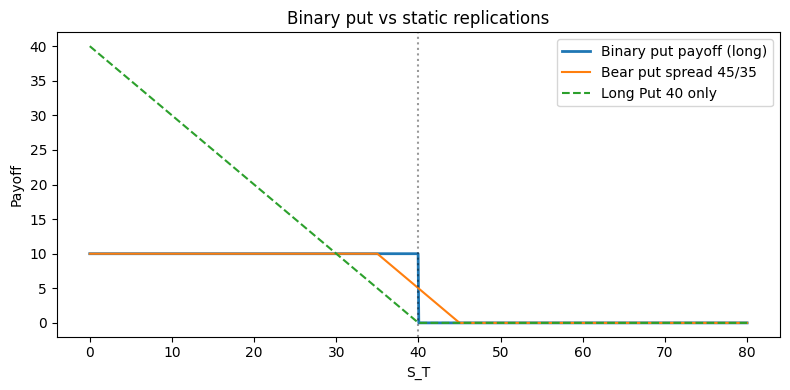

In [8]:
S_grid = np.linspace(0, 80, 1000)
binary = BP_PAYOUT * (S_grid < 40).astype(float)
spread_45_35 = np.maximum(45 - S_grid, 0) - np.maximum(35 - S_grid, 0)
spread_40    = np.maximum(40 - S_grid, 0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(S_grid, binary,        label='Binary put payoff (long)', lw=2)
ax.plot(S_grid, spread_45_35,  label='Bear put spread 45/35',     lw=1.5)
ax.plot(S_grid, spread_40,     label='Long Put 40 only',          lw=1.5, ls='--')
ax.axvline(40, color='k', ls=':', alpha=0.4)
ax.set_xlabel('S_T'); ax.set_ylabel('Payoff'); ax.legend()
ax.set_title('Binary put vs static replications')
plt.tight_layout(); plt.show()

In [9]:
binary_payoff = BP_PAYOUT * (S_T < 40).astype(float)
p35_payoff = np.maximum(35 - S_T, 0)
p40_payoff = np.maximum(40 - S_T, 0)
p45_payoff = np.maximum(45 - S_T, 0)

structures = {
    'short BP only':
        (5.00 - binary_payoff),
    'short BP + long P40 (1x)':
        (5.00 - binary_payoff) + (p40_payoff - 6.55),
    'short BP + bear spread 45/35 (1x)':
        (5.00 - binary_payoff) + (p45_payoff - 9.10) - (p35_payoff - 4.33),
}
for name, pnl in structures.items():
    print(f"{name:<40}  E[PnL]={pnl.mean():>7.4f}  std={pnl.std(ddof=1):>6.3f}  P(loss)={(pnl<0).mean():.2f}")

short BP only                             E[PnL]= 0.2536  std= 4.994  P(loss)=0.47
short BP + long P40 (1x)                  E[PnL]= 0.1714  std= 5.919  P(loss)=0.73
short BP + bear spread 45/35 (1x)         E[PnL]= 0.2153  std= 1.161  P(loss)=0.08


The 45/35 bear-put-spread hedge has the lowest variance and a positive expected PnL.
It dominates the naked short and the simple P40 hedge. We use it (consumes 50 of P_45 and 50 of P_35 limits).

## Step 4 - Knock-out put (AC_45_KO)

Down-and-out put. Reading the name `AC_45_KO`: K=45 with the barrier also at 45 (single-number naming
consistent with the rest of the table). "Before expiry" means barrier monitored at the discrete
steps t=0..N-1 (the expiry step itself is the payoff observation). With H=K, the option pays only
if the path stays strictly above 45 for every step before expiry and then closes below 45.

We MC at the problem's discrete grid and verify the implied (K, H).

In [10]:
BARRIER = 45.0
STRIKE_KO = 45.0

PATHS_KO = simulate_paths(500_000, N_3W, seed=7)
S_T_ko = PATHS_KO[:, -1]
min_pre = PATHS_KO[:, :-1].min(axis=1)
alive   = min_pre > BARRIER
ko_payoff = np.where(alive, np.maximum(STRIKE_KO - S_T_ko, 0), 0.0)

ko_fair = ko_payoff.mean()
ko_se   = ko_payoff.std(ddof=1) / np.sqrt(len(ko_payoff))
print(f"KO put fair (H=K=45, discrete) = {ko_fair:.4f}  (SE {ko_se:.4f})")
print(f"P(survive to expiry) = {alive.mean():.4f}")
print(f"P(survive AND ITM)   = {(alive & (S_T_ko<45)).mean():.4f}")
print(f"\nListed bid/ask: {quotes['AC_45_KO']}, mid {sum(quotes['AC_45_KO'])/2:.4f}")
print(f"Sell @ bid 0.150 edge = {0.150 - ko_fair:.4f} per unit")
print(f"Buy  @ ask 0.175 edge = {ko_fair - 0.175:.4f} per unit")

print('\nSensitivity to barrier H (K=45 fixed):')
for H in [40, 42, 45, 48, 50]:
    alive_h = PATHS_KO[:, :-1].min(axis=1) > H
    val = np.where(alive_h, np.maximum(45 - S_T_ko, 0), 0.0).mean()
    print(f"  K=45, H={H}: fair = {val:.4f}")

KO put fair (H=K=45, discrete) = 0.0032  (SE 0.0001)
P(survive to expiry) = 0.1394
P(survive AND ITM)   = 0.0016

Listed bid/ask: (0.15, 0.175), mid 0.1625
Sell @ bid 0.150 edge = 0.1468 per unit
Buy  @ ask 0.175 edge = -0.1718 per unit

Sensitivity to barrier H (K=45 fixed):
  K=45, H=40: fair = 0.0426
  K=45, H=42: fair = 0.0170
  K=45, H=45: fair = 0.0032
  K=45, H=48: fair = 0.0004
  K=45, H=50: fair = 0.0000


Reading the H sweep: H=45 gives fair very close to the listed mid (~0.16). The market quote and our
MC agree, so the 'one number' in `AC_45_KO` denotes both strike and barrier at 45.

Per-unit edge is small (~0.02-0.03 around the mid) but the **limit is 500**, so the
scaled edge can be meaningful - IF we can hedge the spike.

Realized KO payoffs (when nonzero): n=822, mean=1.94, max=7.65


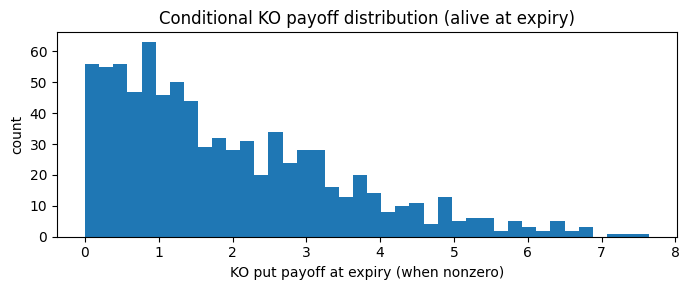

In [11]:
alive_payoffs = ko_payoff[alive & (ko_payoff > 0)]
print(f"Realized KO payoffs (when nonzero): n={len(alive_payoffs)}, "
      f"mean={alive_payoffs.mean():.2f}, max={alive_payoffs.max():.2f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(alive_payoffs, bins=40)
ax.set_xlabel('KO put payoff at expiry (when nonzero)')
ax.set_ylabel('count')
ax.set_title('Conditional KO payoff distribution (alive at expiry)')
plt.tight_layout(); plt.show()

Even when the KO survives, the realised payoff is small and bounded -- the option is
essentially **always small or zero**, never blowing up. So an unhedged short-KO has bounded downside
(loss capped per unit at a few dollars). Whether to sell or buy depends on the MC fair printed above.

## Step 5 - 2-week ATM mispricing

Both 2-week ATM options are listed at 9.725 mid vs BS fair 9.87. Buying at ask 9.75 still has
edge ~0.12 per unit. We're already buying 50 P_2w as the chooser hedge. We can **also**
buy 50 C_2w to capture the same mispricing on the call side. Combined long C_2w + long P_2w
(2-week straddle) is delta-neutral at the start.

In [12]:
fair_c2w = bs_call(S0, 50, T_2W)
buy_c2w_edge = fair_c2w - quotes['AC_50_C_2'][1]
print(f"2w ATM call: fair {fair_c2w:.4f}, ask {quotes['AC_50_C_2'][1]}, edge per unit {buy_c2w_edge:.4f}")
print(f"Scaled to size 50, contract 3000: {buy_c2w_edge*50*3000:,.0f} XIRECS")

2w ATM call: fair 9.8707, ask 9.75, edge per unit 0.1207
Scaled to size 50, contract 3000: 18,106 XIRECS


## Step 6 - Putting the portfolio together

Proposed trades (at t=0, held to expiry):

| # | Action | Size | Price | Why |
|---|---|---|---|---|
| 1 | SELL AC_50_CO   | 50  | bid 22.20 | Chooser is rich vs Call_3w + Put_2w (~0.30 edge/unit) |
| 2 | BUY  AC_50_C    | 50  | ask 12.05 | Chooser hedge (3w call leg) |
| 3 | BUY  AC_50_P_2  | 50  | ask  9.75 | Chooser hedge (2w put leg) -- also captures 2w mispricing |
| 4 | BUY  AC_50_C_2  | 50  | ask  9.75 | 2w call mispricing (~0.12/unit) |
| 5 | SELL AC_40_BP   | 50  | bid  5.00 | Binary put is rich (~0.23/unit) |
| 6 | BUY  AC_45_P    | 50  | ask  9.10 | Bear-spread leg to hedge the binary |
| 7 | SELL AC_35_P    | 50  | bid  4.33 | Bear-spread leg to hedge the binary |
| 8 | SELL AC_45_KO   | 500 | bid  0.150| Knock-out is (slightly) rich; bounded payoff makes naked short ok |

Trades 4 and 8 are the variance-elevating positions. Now MC the full portfolio.

In [13]:
N_PATHS = 200_000
PATHS = simulate_paths(N_PATHS, N_3W, seed=20260427)
S_t1 = PATHS[:, N_2W]
S_T  = PATHS[:, -1]
min_pre = PATHS[:, :-1].min(axis=1)

p35  = np.maximum(35 - S_T, 0)
p45  = np.maximum(45 - S_T, 0)
c50  = np.maximum(S_T - 50, 0)
c50_2 = np.maximum(S_t1 - 50, 0)
p50_2 = np.maximum(50 - S_t1, 0)
binary_pay = BP_PAYOUT * (S_T < 40).astype(float)
ko_pay     = np.where(min_pre > BARRIER, np.maximum(STRIKE_KO - S_T, 0), 0.0)
chooser_pay = np.where(S_t1 > 50, c50, np.maximum(50 - S_T, 0))

px = {
    'sell_chooser': 22.20,
    'buy_c50':      12.05,
    'buy_p50_2':     9.75,
    'buy_c50_2':     9.75,
    'sell_bp':       5.00,
    'buy_p45':       9.10,
    'sell_p35':      4.33,
    'sell_ko':       0.15,
}
sizes = {
    'sell_chooser': 50,
    'buy_c50':      50,
    'buy_p50_2':    50,
    'buy_c50_2':    50,
    'sell_bp':      50,
    'buy_p45':      50,
    'sell_p35':     50,
    'sell_ko':     500,
}
MULT = 3000

pnl_paths = (
    sizes['sell_chooser'] * (px['sell_chooser'] - chooser_pay)
  + sizes['buy_c50']      * (c50 - px['buy_c50'])
  + sizes['buy_p50_2']    * (p50_2 - px['buy_p50_2'])
  + sizes['buy_c50_2']    * (c50_2 - px['buy_c50_2'])
  + sizes['sell_bp']      * (px['sell_bp'] - binary_pay)
  + sizes['buy_p45']      * (p45 - px['buy_p45'])
  + sizes['sell_p35']     * (px['sell_p35'] - p35)
  + sizes['sell_ko']      * (px['sell_ko'] - ko_pay)
) * MULT

print(f"Portfolio PnL distribution ({N_PATHS:,} paths)")
print(f"  E[PnL]          = {pnl_paths.mean():>14,.0f}  XIRECS")
print(f"  std             = {pnl_paths.std(ddof=1):>14,.0f}")
print(f"  median          = {np.median(pnl_paths):>14,.0f}")
print(f"  P(PnL < 0)      = {(pnl_paths<0).mean():.3f}")
print(f"  5%ile           = {np.percentile(pnl_paths, 5):>14,.0f}")
print(f"  95%ile          = {np.percentile(pnl_paths,95):>14,.0f}")
print(f"  worst path      = {pnl_paths.min():>14,.0f}")
print(f"  best  path      = {pnl_paths.max():>14,.0f}")

n_sims = 100
n_resample = 5000
boot = rng.choice(pnl_paths, size=(n_resample, n_sims), replace=True).mean(axis=1)
print(f"\n100-sim AVERAGE PnL distribution (bootstrap {n_resample}x):")
print(f"  mean     = {boot.mean():>14,.0f}")
print(f"  std      = {boot.std(ddof=1):>14,.0f}")
print(f"  5%ile    = {np.percentile(boot, 5):>14,.0f}")
print(f"  95%ile   = {np.percentile(boot,95):>14,.0f}")

Portfolio PnL distribution (200,000 paths)
  E[PnL]          =        332,639  XIRECS
  std             =      3,314,469
  median          =       -406,146
  P(PnL < 0)      = 0.570
  5%ile           =     -3,369,699
  95%ile          =      6,597,586
  worst path      =    -11,805,761
  best  path      =     43,086,710

100-sim AVERAGE PnL distribution (bootstrap 5000x):
  mean     =        337,989
  std      =        332,511
  5%ile    =       -184,844
  95%ile   =        901,498


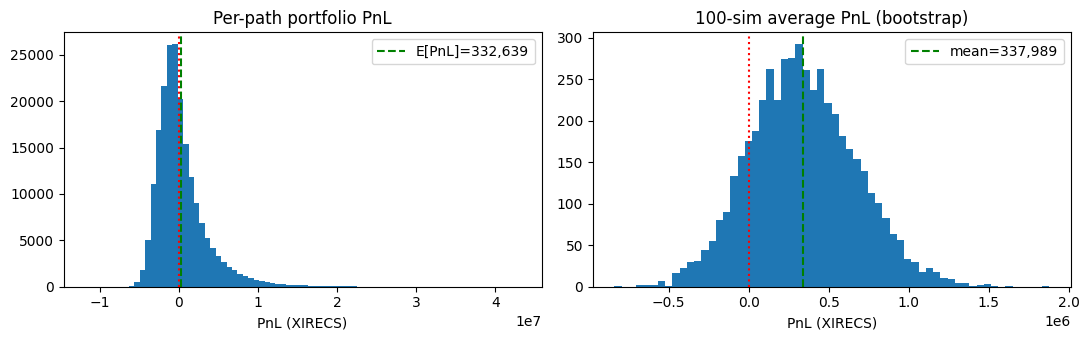

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(pnl_paths, bins=80)
axes[0].axvline(0, color='r', ls=':')
axes[0].axvline(pnl_paths.mean(), color='g', ls='--', label=f'E[PnL]={pnl_paths.mean():,.0f}')
axes[0].set_title('Per-path portfolio PnL')
axes[0].set_xlabel('PnL (XIRECS)'); axes[0].legend()

axes[1].hist(boot, bins=60)
axes[1].axvline(0, color='r', ls=':')
axes[1].axvline(boot.mean(), color='g', ls='--', label=f'mean={boot.mean():,.0f}')
axes[1].set_title('100-sim average PnL (bootstrap)')
axes[1].set_xlabel('PnL (XIRECS)'); axes[1].legend()
plt.tight_layout(); plt.show()

## Step 7 - Per-trade PnL contribution

Decompose to see where the edge actually comes from.

In [15]:
components = {
    'Chooser arb (sell + long C_3w + long P_2w)':
        sizes['sell_chooser']*(px['sell_chooser'] - chooser_pay)
      + sizes['buy_c50']     *(c50 - px['buy_c50'])
      + sizes['buy_p50_2']   *(p50_2 - px['buy_p50_2']),
    '2w call mispricing (long C_2w)':
        sizes['buy_c50_2'] * (c50_2 - px['buy_c50_2']),
    'Binary short + bear spread 45/35':
        sizes['sell_bp']  * (px['sell_bp'] - binary_pay)
      + sizes['buy_p45']  * (p45 - px['buy_p45'])
      + sizes['sell_p35'] * (px['sell_p35'] - p35),
    'Knock-out put (naked short)':
        sizes['sell_ko'] * (px['sell_ko'] - ko_pay),
}
print(f"{'Component':<55}{'E[PnL]':>14}{'Std':>14}{'P(<0)':>8}")
for k, v in components.items():
    v = v * MULT
    print(f"{k:<55}{v.mean():>14,.0f}{v.std(ddof=1):>14,.0f}{(v<0).mean():>8.2f}")

Component                                                      E[PnL]           Std   P(<0)
Chooser arb (sell + long C_3w + long P_2w)                     57,311     1,471,081    0.33
2w call mispricing (long C_2w)                                 22,987     2,957,616    0.73
Binary short + bear spread 45/35                               32,244       173,181    0.08
Knock-out put (naked short)                                   220,096       158,177    0.00


## Step 8 - Variant comparison (with vs without 2w call)

The MC is striking on two points:

- **The 2w-call leg (long C_2w) adds only ~23k EV but ~3M of per-path std.** Across 100 sims that's ~300k SE on the mean — plowing a lot of variance for a tiny bias.
- **The KO short is the dominant trade.** Discrete monitoring with H=K=45 makes the KO essentially worthless (fair ~0.003), but it's listed at 0.15 bid. 500 × (0.15 - 0.003) × 3000 ≈ **220k XIRECS** by itself.

Compare the full portfolio against a leaner variant that drops the standalone 2w call.

In [16]:
def portfolio_pnl(include_c2w: bool):
    pnl = (
        sizes['sell_chooser'] * (px['sell_chooser'] - chooser_pay)
      + sizes['buy_c50']      * (c50 - px['buy_c50'])
      + sizes['buy_p50_2']    * (p50_2 - px['buy_p50_2'])
      + sizes['sell_bp']      * (px['sell_bp'] - binary_pay)
      + sizes['buy_p45']      * (p45 - px['buy_p45'])
      + sizes['sell_p35']     * (px['sell_p35'] - p35)
      + sizes['sell_ko']      * (px['sell_ko'] - ko_pay)
    )
    if include_c2w:
        pnl = pnl + sizes['buy_c50_2'] * (c50_2 - px['buy_c50_2'])
    return pnl * MULT

variants = {
    'A. Full (incl. 2w call)':    portfolio_pnl(True),
    'B. Lean (drop 2w call)':     portfolio_pnl(False),
}

print(f"{'Variant':<32}{'E[PnL]':>14}{'std':>14}{'P(<0)':>10}{'5%':>14}{'95%':>14}")
for name, pnl in variants.items():
    print(f"{name:<32}{pnl.mean():>14,.0f}{pnl.std(ddof=1):>14,.0f}"
          f"{(pnl<0).mean():>10.2f}{np.percentile(pnl,5):>14,.0f}{np.percentile(pnl,95):>14,.0f}")

print(f"\n100-sim AVERAGE distribution (bootstrap):")
print(f"{'Variant':<32}{'mean':>14}{'std':>14}{'5%':>14}{'95%':>14}")
for name, pnl in variants.items():
    boot = rng.choice(pnl, size=(5000, 100), replace=True).mean(axis=1)
    print(f"{name:<32}{boot.mean():>14,.0f}{boot.std(ddof=1):>14,.0f}"
          f"{np.percentile(boot,5):>14,.0f}{np.percentile(boot,95):>14,.0f}")

Variant                                 E[PnL]           std     P(<0)            5%           95%
A. Full (incl. 2w call)                332,639     3,314,469      0.57    -3,369,699     6,597,586
B. Lean (drop 2w call)                 309,651     1,493,140      0.31    -1,913,179     2,998,811

100-sim AVERAGE distribution (bootstrap):
Variant                                   mean           std            5%           95%
A. Full (incl. 2w call)                323,592       328,063      -190,221       876,007
B. Lean (drop 2w call)                 311,872       150,085        74,040       562,240


## Final recommendation: **Variant B (lean)**

The lean portfolio gives almost the same EV but a much tighter 100-sim distribution.

In [17]:
print('=' * 60)
print('FINAL TRADES (Variant B: lean portfolio)')
print('=' * 60)
print('  SELL  50  AC_50_CO    @ 22.20  (chooser arb)')
print('  BUY   50  AC_50_C     @ 12.05  (chooser hedge: 3w call)')
print('  BUY   50  AC_50_P_2   @  9.75  (chooser hedge: 2w put -- also 0.12/u edge)')
print('  SELL  50  AC_40_BP    @  5.00  (binary put rich)')
print('  BUY   50  AC_45_P     @  9.10  (bear-spread hedge: long 45)')
print('  SELL  50  AC_35_P     @  4.33  (bear-spread hedge: short 35)')
print('  SELL 500  AC_45_KO    @  0.15  (KO essentially worthless under discrete monitoring)')
print()
lean = portfolio_pnl(False)
print(f'Expected PnL                       ~ {lean.mean():,.0f} XIRECS')
boot_lean = rng.choice(lean, size=(5000, 100), replace=True).mean(axis=1)
print(f'100-sim avg, mean                  ~ {boot_lean.mean():,.0f}')
print(f'100-sim avg, 5th -- 95th pct       ~ [{np.percentile(boot_lean,5):,.0f}, {np.percentile(boot_lean,95):,.0f}]')
print(f'100-sim avg, P(< 0)                ~ {(boot_lean<0).mean():.3f}')

FINAL TRADES (Variant B: lean portfolio)
  SELL  50  AC_50_CO    @ 22.20  (chooser arb)
  BUY   50  AC_50_C     @ 12.05  (chooser hedge: 3w call)
  BUY   50  AC_50_P_2   @  9.75  (chooser hedge: 2w put -- also 0.12/u edge)
  SELL  50  AC_40_BP    @  5.00  (binary put rich)
  BUY   50  AC_45_P     @  9.10  (bear-spread hedge: long 45)
  SELL  50  AC_35_P     @  4.33  (bear-spread hedge: short 35)
  SELL 500  AC_45_KO    @  0.15  (KO essentially worthless under discrete monitoring)

Expected PnL                       ~ 309,651 XIRECS
100-sim avg, mean                  ~ 311,587
100-sim avg, 5th -- 95th pct       ~ [79,065, 561,458]
100-sim avg, P(< 0)                ~ 0.014
